# 🚢 Titanic Survival Prediction — Complete Kaggle Notebook

**Workflow:** Libraries → Data Loading → Inspection → EDA → Cleaning → Feature Engineering → Preprocessing → Train/Validation Split → Model Training → Evaluation → Model Comparison → Final Model → Submission

Kaggle competition: Titanic — Machine Learning from Disaster

In [2]:
# Cell 1 — Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Cell 2 — Load Dataset
train_path = r"titanic\train.csv"
test_path = r"titanic\test.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (891, 12)
Test shape: (418, 11)


In [4]:
# Cell 3 — First Look
display(train.head())
display(train.tail())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
# Cell 4 — Dataset Information
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
# Cell 5 — Statistical Summary
display(train.describe())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# Cell 6 — Missing Values
print("Missing values in TRAIN:")
print(train.isnull().sum())

print("\nMissing values in TEST:")
print(test.isnull().sum())

Missing values in TRAIN:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values in TEST:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [8]:
# Cell 7 — Duplicate Rows
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


## 📊 Exploratory Data Analysis (EDA)

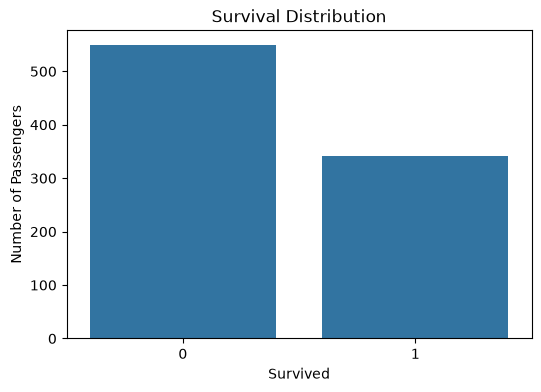

In [9]:
# Cell 8 — Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=train, x="Survived")
plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.show()

In [10]:
# Cell 9 — Survival Percentage
survival_percentage = train["Survived"].value_counts(normalize=True) * 100
print(survival_percentage)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


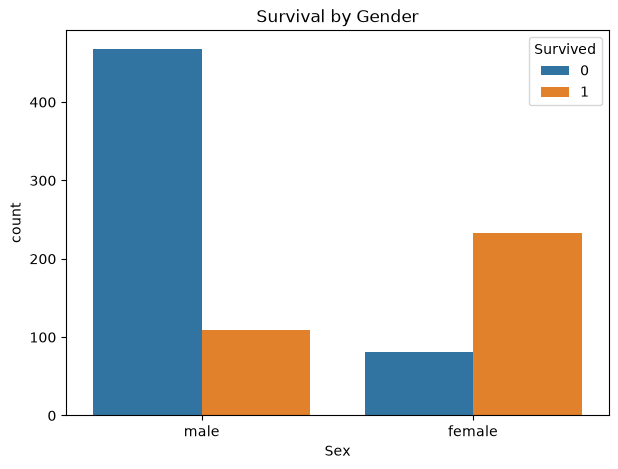

In [11]:
# Cell 10 — Survival by Gender
plt.figure(figsize=(7, 5))
sns.countplot(data=train, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.show()

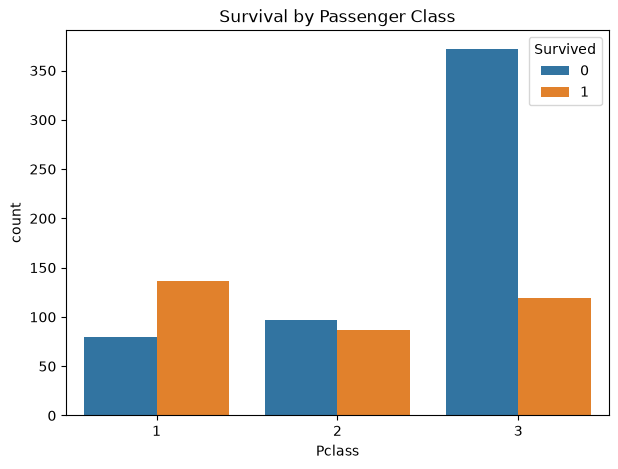

In [12]:
# Cell 11 — Survival by Passenger Class
plt.figure(figsize=(7, 5))
sns.countplot(data=train, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()

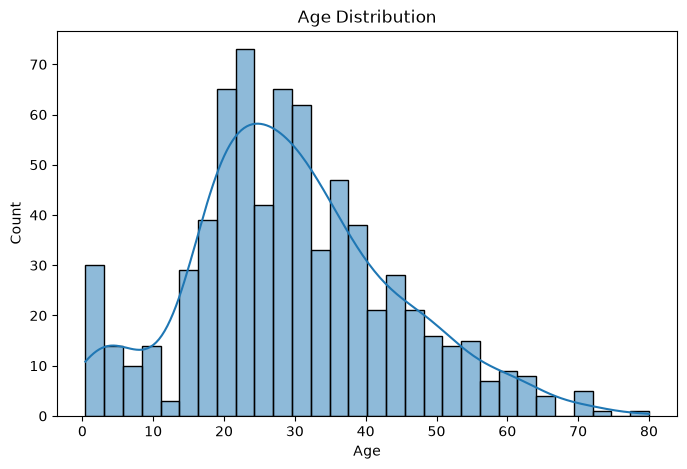

In [13]:
# Cell 12 — Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=train, x="Age", bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

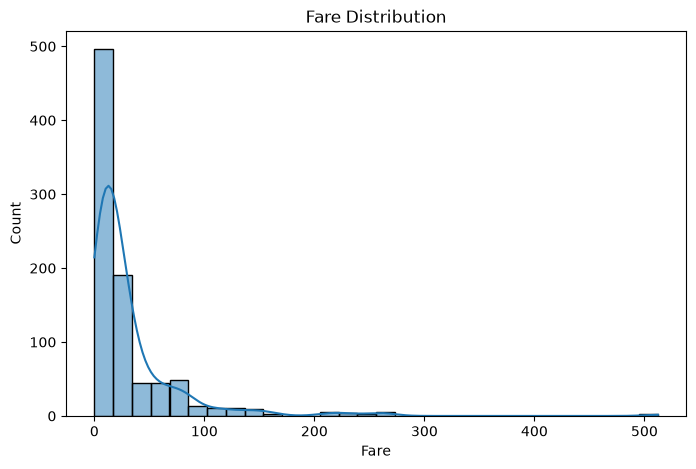

In [14]:
# Cell 13 — Fare Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=train, x="Fare", bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

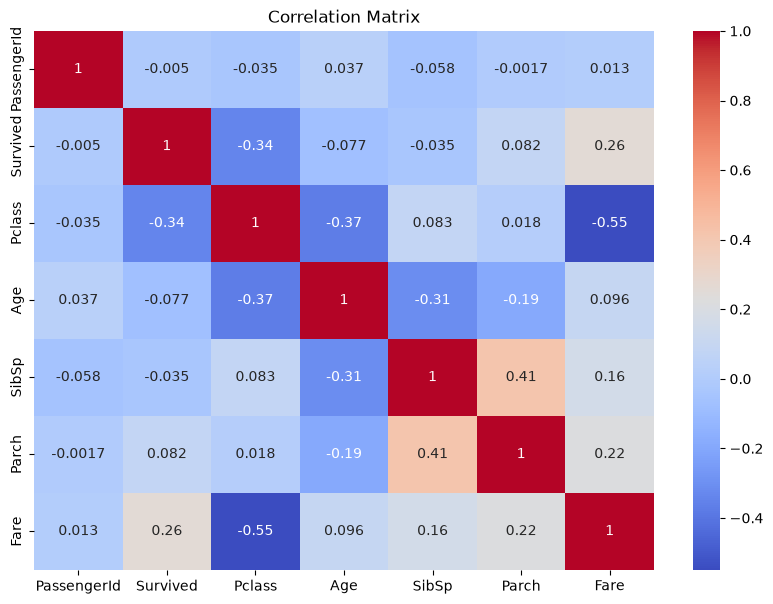

In [15]:
# Cell 14 — Correlation Matrix
numeric_data = train.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## 🧹 Data Cleaning

In [16]:
# Cell 15 — Create Clean Copies
train_clean = train.copy()
test_clean = test.copy()

print("Train:", train_clean.shape)
print("Test:", test_clean.shape)

Train: (891, 12)
Test: (418, 11)


In [17]:
# Cell 16 — Fill Missing Age
train_clean["Age"] = train_clean["Age"].fillna(train_clean["Age"].median())
test_clean["Age"] = test_clean["Age"].fillna(train_clean["Age"].median())

In [18]:
# Cell 17 — Fill Missing Embarked
train_clean["Embarked"] = train_clean["Embarked"].fillna(train_clean["Embarked"].mode()[0])
test_clean["Embarked"] = test_clean["Embarked"].fillna(train_clean["Embarked"].mode()[0])

In [19]:
# Cell 18 — Fill Missing Fare
test_clean["Fare"] = test_clean["Fare"].fillna(train_clean["Fare"].median())

In [20]:
# Cell 19 — Check Missing Values Again
print("TRAIN missing values:")
print(train_clean.isnull().sum())

print("\nTEST missing values:")
print(test_clean.isnull().sum())

TRAIN missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

TEST missing values:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64


## 🧠 Feature Engineering

In [21]:
# Cell 20 — Family Size
train_clean["FamilySize"] = train_clean["SibSp"] + train_clean["Parch"] + 1
test_clean["FamilySize"] = test_clean["SibSp"] + test_clean["Parch"] + 1

display(train_clean[["SibSp", "Parch", "FamilySize"]].head())

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [22]:
# Cell 21 — Is Alone
train_clean["IsAlone"] = (train_clean["FamilySize"] == 1).astype(int)
test_clean["IsAlone"] = (test_clean["FamilySize"] == 1).astype(int)

display(train_clean[["FamilySize", "IsAlone"]].head())

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


In [23]:
# Cell 22 — Extract Title from Name
train_clean["Title"] = train_clean["Name"].str.extract(r",\s*([^.]*)\.")
test_clean["Title"] = test_clean["Name"].str.extract(r",\s*([^.]*)\.")

print(train_clean["Title"].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


In [24]:
# Cell 23 — Group Rare Titles
common_titles = ["Mr", "Miss", "Mrs", "Master"]

train_clean["Title"] = train_clean["Title"].where(
    train_clean["Title"].isin(common_titles), "Rare"
)

test_clean["Title"] = test_clean["Title"].where(
    test_clean["Title"].isin(common_titles), "Rare"
)

print(train_clean["Title"].value_counts())

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


In [25]:
# Cell 24 — Select Features
drop_columns = ["Survived", "PassengerId", "Name", "Ticket", "Cabin"]

X = train_clean.drop(columns=drop_columns)
y = train_clean["Survived"]

X_test = test_clean.drop(
    columns=["PassengerId", "Name", "Ticket", "Cabin"]
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (891, 10)
y shape: (891,)
X_test shape: (418, 10)


## 🔢 Preprocessing

In [26]:
# Cell 25 — One-Hot Encode Categorical Features
X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked", "Title"],
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=["Sex", "Embarked", "Title"],
    drop_first=True
)

# Make sure test columns match training columns
X_test = X_test.reindex(columns=X.columns, fill_value=0)

print("Final training features:")
print(X.columns.tolist())

Final training features:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


## ✂️ Train / Validation Split

In [27]:
# Cell 26 — Split Data
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Validation data:", X_valid.shape)

Training data: (712, 14)
Validation data: (179, 14)


## 🤖 Model Training

In [28]:
# Cell 27 — Logistic Regression
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)
logistic_pred = logistic_model.predict(X_valid)

logistic_accuracy = accuracy_score(y_valid, logistic_pred)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.8547486033519553


In [29]:
# Cell 28 — Decision Tree
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_valid)

tree_accuracy = accuracy_score(y_valid, tree_pred)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.7988826815642458


In [30]:
# Cell 29 — Random Forest
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_valid)

rf_accuracy = accuracy_score(y_valid, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8379888268156425


In [31]:
# Cell 30 — Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_valid)

gb_accuracy = accuracy_score(y_valid, gb_pred)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.8212290502793296


## 🏆 Model Comparison

In [32]:
# Cell 31 — Compare Models
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy,
        gb_accuracy
    ]
})

results = results.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
display(results)

,Model,Accuracy
0,Logistic Regression,0.854749
1,Random Forest,0.837989
2,Gradient Boosting,0.821229
3,Decision Tree,0.798883


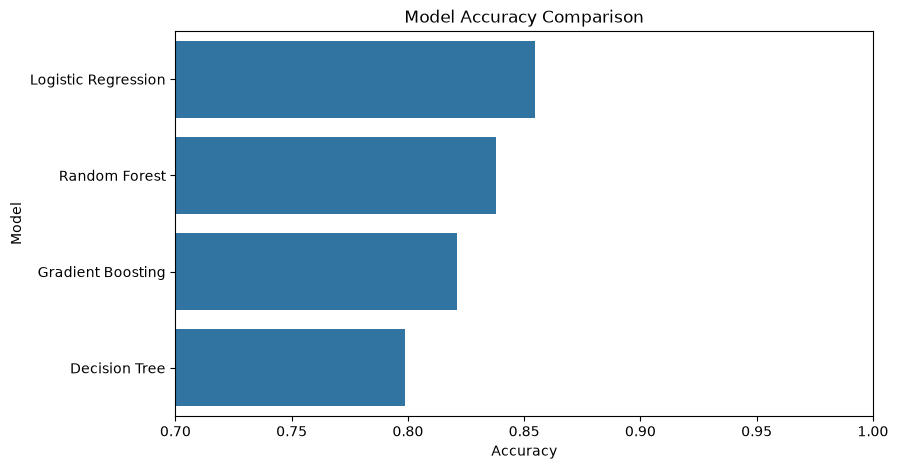

In [33]:
# Cell 32 — Visualize Model Performance
plt.figure(figsize=(9, 5))
sns.barplot(data=results, x="Accuracy", y="Model")
plt.title("Model Accuracy Comparison")
plt.xlim(0.70, 1.00)
plt.show()

## 🧪 Model Evaluation

In [34]:
# Cell 33 — Classification Report
# Using Random Forest for detailed evaluation
print(classification_report(y_valid, rf_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87       110
           1       0.83      0.72      0.78        69

    accuracy                           0.84       179
   macro avg       0.84      0.82      0.82       179
weighted avg       0.84      0.84      0.84       179



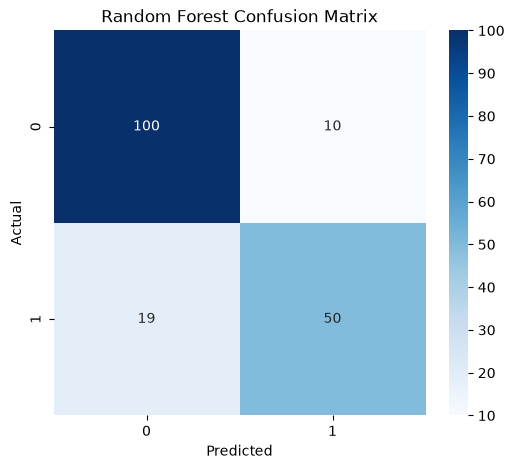

In [35]:
# Cell 34 — Confusion Matrix
cm = confusion_matrix(y_valid, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

## 🚢 Final Model & Kaggle Submission

In [36]:
# Cell 35 — Train Final Random Forest on Full Training Data
final_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    random_state=42
)

final_model.fit(X, y)

print("Final model trained successfully!")

Final model trained successfully!


In [ ]:
# Cell 36 — Predict Test Data
test_predictions = final_model.predict(X_test)

print("First 20 predictions:")
print(test_predictions[:20])

In [ ]:
# Cell 37 — Create submission.csv
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_predictions
})

submission.to_csv(
    "/kaggle/working/submission.csv",
    index=False
)

print("submission.csv created successfully!")

In [ ]:
# Cell 38 — Verify Submission
display(submission.head(10))

print("Submission shape:", submission.shape)
print("Columns:", submission.columns.tolist())

assert submission.shape == (len(test), 2)
assert submission.columns.tolist() == ["PassengerId", "Survived"]
assert submission["Survived"].isin([0, 1]).all()

print("\nSubmission file looks correct!")

In [ ]:
# Cell 39 — Optional: Check Saved File
import os

file_path = "/kaggle/working/submission.csv"

print("File exists:", os.path.exists(file_path))
print("File path:", file_path)

## 📤 Final Kaggle Steps

1. Run **Save Version / Save & Run All**.
2. Find `submission.csv` in the notebook output/files.
3. Go to the Titanic competition page.
4. Choose **Submit Predictions**.
5. Upload `submission.csv`.
6. Submit and check your leaderboard score.

## 🐙 GitHub

Recommended repository:

```text
Titanic-Survival-Prediction/
├── Titanic_Survival_Prediction.ipynb
├── submission.csv
├── README.md
└── requirements.txt
```

For a portfolio project, upload the notebook and README. You don't need to upload Kaggle's original raw dataset files.